C:\Users\Aidam\AppData\Local\Temp\ipykernel_32888\619274087.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('merge.csv')


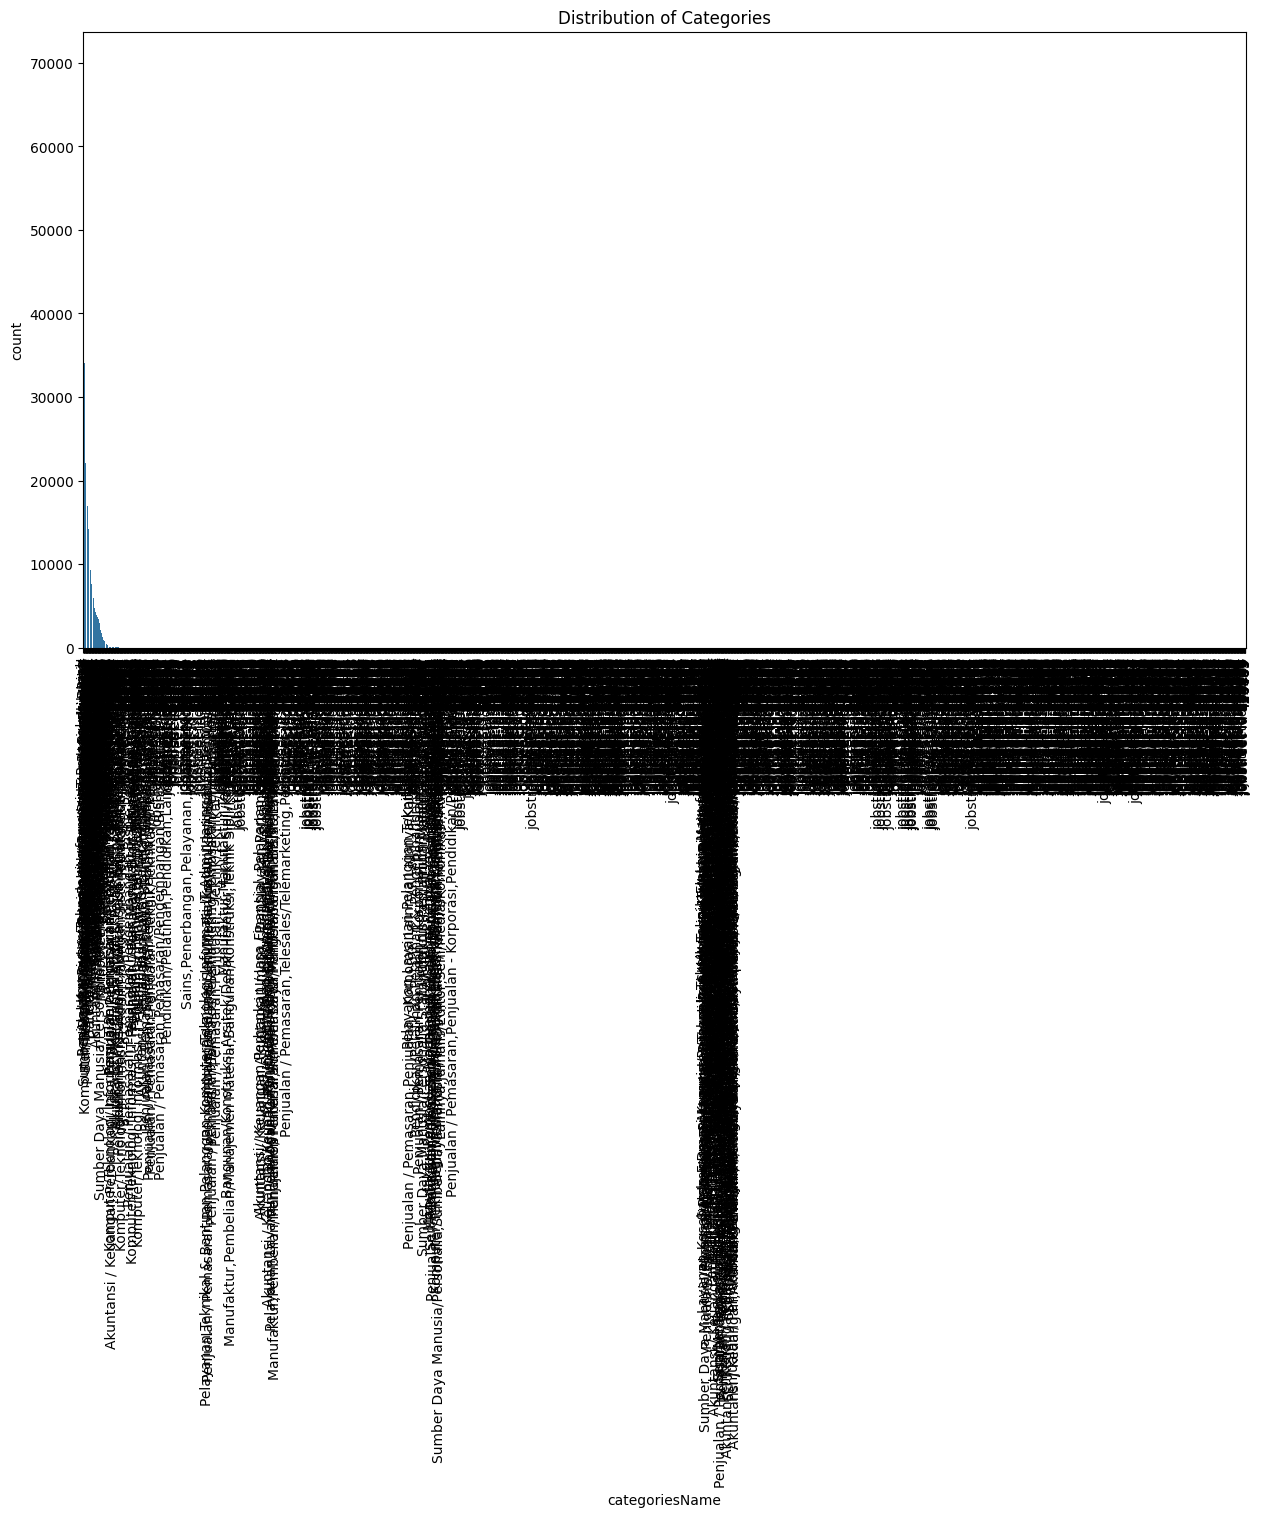

In [17]:
import pandas as pd
df = pd.read_csv('merge.csv')

import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
sns.countplot(x='categoriesName', data=df, order=df['categoriesName'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Distribution of Categories')
plt.show()

In [18]:
# Define a mapping from detailed categories to a more general 'skill'
skill_map = {
    'Penjualan / Pemasaran': 'Penjualan & Pemasaran',
    'Pemasaran/Pengembangan Bisnis': 'Penjualan & Pemasaran',
    'Penjualan Ritel': 'Penjualan & Pemasaran',
    'Penjualan - Korporasi': 'Penjualan & Pemasaran',
    'Penjualan - Teknik/Teknikal/IT': 'Penjualan & Pemasaran',
    'Penjualan - Jasa Keuangan': 'Penjualan & Pemasaran',
    'Telesales/Telemarketing': 'Penjualan & Pemasaran',
    'Digital Marketing': 'Penjualan & Pemasaran',
    'Merchandising': 'Penjualan & Pemasaran',
    'E-commerce': 'Penjualan & Pemasaran',
    'Periklanan/Hubungan Masyarakat': 'Penjualan & Pemasaran',
    'Periklanan': 'Penjualan & Pemasaran',
    'Akuntansi / Keuangan': 'Akuntansi & Keuangan',
    'Akuntansi Umum / Pembiayaan': 'Akuntansi & Keuangan',
    'Perbankan / Jasa Finansial': 'Akuntansi & Keuangan',
    'Audit & Pajak': 'Akuntansi & Keuangan',
    'Keuangan/Investasi Perusahaan': 'Akuntansi & Keuangan',
    'Aktuaria/Statistik': 'Akuntansi & Keuangan',
    'Layanan Pelanggan': 'Layanan Pelanggan',
    'Pelayanan, Teknikal & Bantuan Pelanggan': 'Layanan Pelanggan',
    'Perawatan Pribadi': 'Layanan Pelanggan',
    'Teknikal & Bantuan Pelanggan': 'Layanan Pelanggan',
    'Manufaktur': 'Manufaktur',
    'Pembelian/Manajemen Material': 'Manufaktur',
    'Pemeliharaan': 'Manufaktur',
    'Penjaminan Kualitas / QA': 'Manufaktur',
    'Kontrol Proses': 'Manufaktur',
    'Teknik': 'Teknik',
    'Teknik Kimia': 'Teknik',
    'Teknik Elektro': 'Teknik',
    'Teknik Mesin': 'Teknik',
    'Teknik Industri': 'Teknik',
    'Teknik Sipil/Konstruksi Bangunan': 'Konstruksi',
    'Teknik Lingkungan': 'Teknik',
    'Mekanikal': 'Teknik',
    'Teknik Elektronika': 'Teknik',
    'Teknik Lainnya': 'Teknik',
    'Minyak/Gas': 'Teknik',
    'Komputer/Teknologi Informasi': 'IT',
    'IT-Perangkat Lunak': 'IT',
    'IT-Admin Jaringan/Sistem/Database': 'IT',
    'IT-Perangkat Keras': 'IT',
    'Hotel/Restoran': 'Layanan Pelanggan',
    'Makanan/Minuman/Pelayanan Restoran': 'Layanan Pelanggan',
    'Hotel/Pariwisata': 'Layanan Pelanggan',
    'Seni/Media/Komunikasi': 'Seni, Media & Komunikasi',
    'Seni / Desain Kreatif': 'Seni, Media & Komunikasi',
    'Hubungan Masyarakat': 'Seni, Media & Komunikasi',
    'Jurnalis/Editor': 'Seni, Media & Komunikasi',
    'Hiburan/Seni Panggung': 'Seni, Media & Komunikasi',
    'Penerbitan': 'Seni, Media & Komunikasi',
    'Sumber Daya Manusia': 'Sumber Daya Manusia',
    'Sumber Daya Manusia / HR': 'Sumber Daya Manusia',
    'Manajemen/Personalia, Top Management': 'Manajemen',
    'Top Management / Manajemen Tingkat Atas': 'Manajemen',
    'Pendidikan': 'Pendidikan',
    'Pelatihan & Pengembangan': 'Pendidikan',
    'Bangunan/Konstruksi': 'Konstruksi',
    'Teknik/Konstruksi Bangunan': 'Konstruksi',
    'Properti/Real Estate': 'Properti',
    'Arsitek/Desain Interior': 'Konstruksi',
    'Survei Kuantitas': 'Konstruksi',
    'Kesehatan': 'Kesehatan',
    'Praktisi/Asisten Medis': 'Kesehatan',
    'Diagnosa/Lainnya': 'Kesehatan',
    'Farmasi': 'Kesehatan',
    'Transportasi/Logistik': 'Logistik',
    'Logistik/Rantai Pasokan': 'Logistik',
    'Sains': 'Sains',
    'Bioteknologi': 'Sains',
    'Geologi/Geofisika': 'Sains',
    'Teknologi Makanan/Ahli Gizi': 'Sains',
    'Kimia': 'Sains',
    'Sains & Teknologi': 'IT',
    'Hukum/Legal': 'Hukum',
    'Pengacara / Asisten Legal': 'Hukum',
    'Asuransi': 'Asuransi',
    'Pertambangan': 'Pertambangan',
    'Pertanian': 'Pertanian',
    'Pelayanan sosial/Pengembangan Masyarakat': 'Sosial',
    'Layanan Sosial/Konseling': 'Sosial',
    'Umum': 'Umum',
    'Staf / Administrasi umum': 'Umum',
    'Pekerjaan Umum': 'Umum',
    'Sekretaris': 'Umum',
    'Angkatan Bersenjata': 'guns',
    'Lainnya/Kategori tidak tersedia': 'Lainnya'
}

def map_category_to_skill(category_string):
    """
    Maps a category string (which may contain multiple categories)
    to a single skill based on the skill_map.
    """
    if not isinstance(category_string, str):
        return 'Lainnya'
    
    # Split the string into individual categories
    categories = [cat.strip() for cat in category_string.split(',')]
    
    # Find the first category that has a mapping
    for cat in categories:
        # Check for a direct match or a prefix match in the map
        for key, value in skill_map.items():
            if cat.startswith(key):
                return value
                
    return 'Lainnya' # Default for categories not in the map

# Apply the mapping function to create the new 'skill' column
df['skill'] = df['categoriesName'].apply(map_category_to_skill)

# Display the DataFrame with the new 'skill' column and the value counts
print(df[['categoriesName', 'skill']].head())
print(df['skill'].value_counts())
print(df['skill'].count())

                                      categoriesName                skill
0  Sumber Daya Manusia/Personalia,Sumber Daya Man...  Sumber Daya Manusia
1    Komputer/Teknologi Informasi,IT-Perangkat Lunak                   IT
2                    Pendidikan/Pelatihan,Pendidikan           Pendidikan
3  Komputer/Teknologi Informasi,IT-Admin Jaringan...                   IT
4                    Pendidikan/Pelatihan,Pendidikan           Pendidikan
skill
Penjualan & Pemasaran       160494
IT                           90300
Akuntansi & Keuangan         69234
Layanan Pelanggan            64865
Sumber Daya Manusia          48342
Seni, Media & Komunikasi     31692
Manufaktur                   30766
Teknik                       27276
Pendidikan                   18724
Konstruksi                   18578
Logistik                     16937
Lainnya                      12465
Kesehatan                    12460
Sains                         8948
Hukum                         6966
Umum                     

In [19]:
# Create a new DataFrame with only the 'skill' column
skill_df = df[['skill']]

# Save the new DataFrame to a CSV file named 'skill.csv'
skill_df.to_csv('skill.csv', index=False)

print("'skill' data has been successfully saved to skill.csv")

'skill' data has been successfully saved to skill.csv
